1 — Montar Drive e instalar dependencias

## 📦 0. Verificación del entorno

Antes de comenzar, verificamos que las librerías principales estén disponibles y que exista una GPU para acelerar el entrenamiento. En Google Colab se puede montar Google Drive para acceder al dataset; en ejecución local esa línea puede comentarse.

In [8]:
# Celda 1 — Verificar e instalar dependencias
#!pip install torch torchvision scikit-learn seaborn scikit-image tqdm opencv-python

import torch
import torchvision
print(f"✓ PyTorch: {torch.__version__}")
print(f"✓ Torchvision: {torchvision.__version__}")
print(f"✓ GPU disponible: {torch.cuda.is_available()}")

#from google.colab import drive
#drive.mount('/content/drive')

✓ PyTorch: 2.12.0+cu130
✓ Torchvision: 0.27.0+cu130
✓ GPU disponible: False


### Importaciones principales

Se cargan PyTorch y Torchvision, que son el núcleo del pipeline de deep learning. Se confirma la versión instalada y la disponibilidad de GPU.

In [10]:
# Celda 1 — Verificar e instalar dependencias
#!pip install torch torchvision scikit-learn seaborn scikit-image tqdm

import torch
import torchvision
from pathlib import Path
print(f"✓ PyTorch: {torch.__version__}")
print(f"✓ Torchvision: {torchvision.__version__}")
print(f"✓ GPU disponible: {torch.cuda.is_available()}")

#from google.colab import drive
#drive.mount('/content/drive')

✓ PyTorch: 2.12.0+cu130
✓ Torchvision: 0.27.0+cu130
✓ GPU disponible: False


## 🗂️ 1. Inspección del dataset original

Se recorre el directorio `dataset_400` para listar cuántas imágenes hay por clase (`damaged`, `ripe`, `unripe`). Esto permite detectar desbalances antes del entrenamiento.

In [11]:
# Verificar qué carpetas existen exactamente
BASE = Path("./dataset_400")

print("Carpetas encontradas:")
for carpeta in sorted(BASE.iterdir()):
    if carpeta.is_dir():
        imgs = list(carpeta.glob("*.*"))
        print(f"  '{carpeta.name}' → {len(imgs)} imágenes")

Carpetas encontradas:
  'damaged' → 400 imágenes
  'ripe' → 400 imágenes
  'unripe' → 400 imágenes


2 — Dividir el dataset 70/30 automáticamente

## ✂️ 2. División del dataset (Train 70 % / Val 30 %)

El dataset original se divide aleatoriamente en conjuntos de entrenamiento (70 %) y validación (30 %) usando `random.seed(42)` para reproducibilidad. Los nombres de las carpetas se mapean al español (`damaged → danado`, `ripe → maduro`, `unripe → inmaduro`) y la estructura resultante se guarda en `ripentom_split/`.

In [ ]:
import os, shutil, random
from pathlib import Path

# ── Ruta a tu dataset en Drive ──────────────────────────────────────
BASE = Path("./dataset_400")
DEST = Path("./ripentom_split")

# Mapeo de nombres originales → nombres del código
CLASES = ["damaged", "ripe", "unripe",]
SPLIT  = 0.70
random.seed(42)

for nombre_clase in CLASES:
    imgs = list((BASE / nombre_clase).glob("*.*"))
    random.shuffle(imgs)
    n_train = int(len(imgs) * SPLIT)

    for split, subset in [("train", imgs[:n_train]), ("val", imgs[n_train:])]:
        dest_dir = DEST / split / nombre_clase
        dest_dir.mkdir(parents=True, exist_ok=True)
        for img in subset:
            shutil.copy(img, dest_dir / img.name)

    print(f"{nombre_clase}: {n_train} train | {len(imgs)-n_train} val")

print("\n✓ Dataset dividido en /content/ripentom_split")

danado: 280 train | 120 val
maduro: 280 train | 120 val
inmaduro: 280 train | 120 val

✓ Dataset dividido en /content/ripentom_split


3 — Transformaciones y DataLoaders

## 🔄 3. Transformaciones y DataLoaders

Se definen dos pipelines de transformación:

- **Train**: redimensiona a 224×224, aplica *data augmentation* (flip horizontal/vertical, rotación ±15°, variación de brillo/contraste/saturación) y normaliza con las estadísticas de ImageNet.  
- **Val**: solo redimensiona y normaliza (sin augmentation para una evaluación limpia).

Los `DataLoader` gestionan la carga en lotes de 16 imágenes con mezcla aleatoria en entrenamiento.

In [13]:
import torch.nn as nn
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = ImageFolder(DEST / "train", transform=train_tf)
val_ds   = ImageFolder(DEST / "val",   transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=16)

print(f"Train: {len(train_ds)} imgs | Val: {len(val_ds)} imgs")
print(f"Clases: {train_ds.classes}")

Dispositivo: cpu
Train: 840 imgs | Val: 360 imgs
Clases: ['danado', 'inmaduro', 'maduro']


4 — Modelo MobileNetV3

## 🧠 4. Definición del modelo — MobileNetV3-Small

Se utiliza **MobileNetV3-Small** preentrenado en ImageNet como backbone. Solo se reemplaza la última capa lineal del clasificador para producir 3 salidas (danado, inmaduro, maduro).

Se definen también las funciones `train_epoch` y `val_epoch` que ejecutan una época completa de entrenamiento o validación y retornan pérdida, accuracy y predicciones.

In [14]:
model = models.mobilenet_v3_small(weights="IMAGENET1K_V1")
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

def train_epoch(loader, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (model(imgs).argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def val_epoch(loader):
    model.eval()
    correct, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return correct / len(loader.dataset), all_preds, all_labels

print("✓ Modelo listo")

✓ Modelo listo


5 — Fase 1: backbone congelado (5 epochs)

## 🧊 5. Fase 1 — Entrenamiento con backbone congelado (5 épocas)

En la primera fase se **congela todo el backbone** (`model.features`) y solo se entrenan los pesos del clasificador. Esto permite que las nuevas capas converjan rápidamente aprovechando las representaciones de ImageNet sin distorsionar las capas convolucionales ya aprendidas.

In [15]:
for param in model.features.parameters():
    param.requires_grad = False

opt1 = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
hist = {"train_acc": [], "val_acc": [], "loss": []}

print("=== FASE 1: solo clasificador ===")
for ep in range(5):
    loss, tr_acc = train_epoch(train_loader, opt1)
    val_acc, _, _ = val_epoch(val_loader)
    hist["train_acc"].append(tr_acc)
    hist["val_acc"].append(val_acc)
    hist["loss"].append(loss)
    print(f"Ep {ep+1}/5 | loss={loss:.3f} | train={tr_acc:.3f} | val={val_acc:.3f}")

=== FASE 1: solo clasificador ===
Ep 1/5 | loss=0.762 | train=0.692 | val=0.358
Ep 2/5 | loss=0.637 | train=0.738 | val=0.625
Ep 3/5 | loss=0.615 | train=0.771 | val=0.694
Ep 4/5 | loss=0.622 | train=0.774 | val=0.761
Ep 5/5 | loss=0.581 | train=0.768 | val=0.758


6 — Fase 2: fine-tuning últimas capas (10 epochs)

## 🔥 6. Fase 2 — Fine-tuning de las últimas capas (10 épocas)

En la segunda fase se **descongelan los bloques 10+ del backbone** y se entrena junto al clasificador con una tasa de aprendizaje baja (5e-5) para adaptar las características de alto nivel al dominio de los tomates. Se guarda el modelo con mejor accuracy en validación (`ripentom_best.pth`).

In [16]:
for i, block in enumerate(model.features):
    for param in block.parameters():
        param.requires_grad = (i >= 10)

opt2 = torch.optim.Adam([
    {"params": [p for b in model.features[10:] for p in b.parameters()], "lr": 5e-5},
    {"params": model.classifier.parameters(), "lr": 5e-5},
])

best_val, best_preds, best_labels = 0, [], []

print("=== FASE 2: fine-tuning ===")
for ep in range(10):
    loss, tr_acc = train_epoch(train_loader, opt2)
    val_acc, preds, labels = val_epoch(val_loader)
    hist["train_acc"].append(tr_acc)
    hist["val_acc"].append(val_acc)
    hist["loss"].append(loss)
    print(f"Ep {ep+1}/10 | loss={loss:.3f} | train={tr_acc:.3f} | val={val_acc:.3f}")

    if val_acc > best_val:
        best_val = val_acc
        best_preds, best_labels = preds, labels
        torch.save(model.state_dict(), "./ripentom_best.pth")
        print(f"  -> Guardado ✓ (val={val_acc:.3f})")

=== FASE 2: fine-tuning ===
Ep 1/10 | loss=0.550 | train=0.763 | val=0.756
  -> Guardado ✓ (val=0.756)
Ep 2/10 | loss=0.537 | train=0.793 | val=0.756
Ep 3/10 | loss=0.535 | train=0.788 | val=0.758
  -> Guardado ✓ (val=0.758)
Ep 4/10 | loss=0.494 | train=0.811 | val=0.753
Ep 5/10 | loss=0.515 | train=0.788 | val=0.756
Ep 6/10 | loss=0.500 | train=0.805 | val=0.778
  -> Guardado ✓ (val=0.778)
Ep 7/10 | loss=0.493 | train=0.798 | val=0.772
Ep 8/10 | loss=0.479 | train=0.818 | val=0.772
Ep 9/10 | loss=0.484 | train=0.788 | val=0.783
  -> Guardado ✓ (val=0.783)
Ep 10/10 | loss=0.480 | train=0.815 | val=0.781


7 — Resultados y gráficas para el informe

## 📊 7. Resultados del modelo de Deep Learning

Se genera el reporte de clasificación por clase (precisión, recall, F1) y se visualizan:

1. **Matriz de confusión** — muestra dónde se confunden las clases.  
2. **Curva de entrenamiento** — accuracy de train y validación a lo largo de las 15 épocas, con una línea vertical que marca el inicio del fine-tuning.


Mejor val_acc: 0.783

              precision    recall  f1-score   support

      danado       0.83      0.66      0.73       120
    inmaduro       0.86      0.93      0.89       120
      maduro       0.68      0.77      0.72       120

    accuracy                           0.78       360
   macro avg       0.79      0.78      0.78       360
weighted avg       0.79      0.78      0.78       360



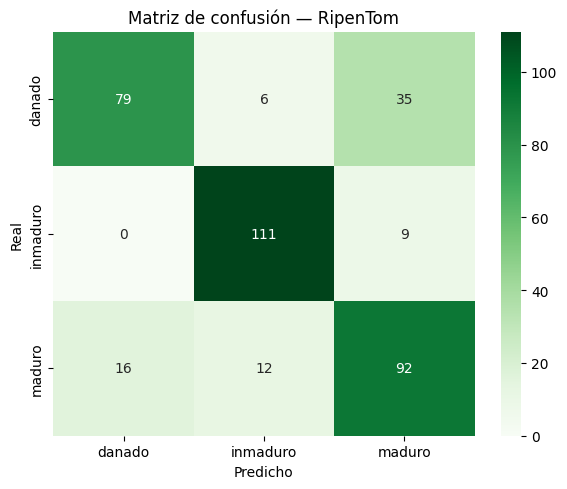

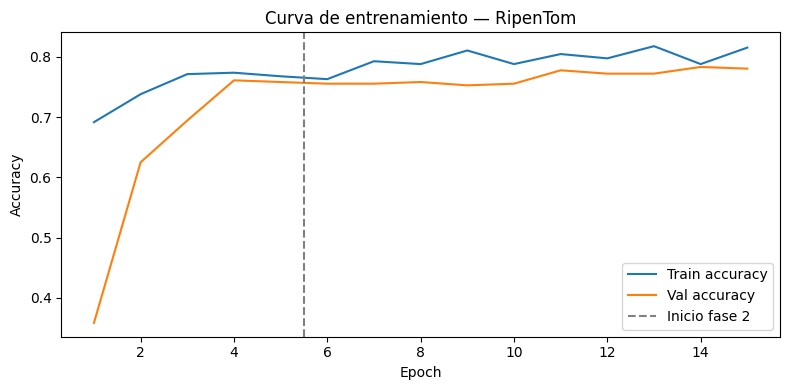

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

CLASES_NOMBRES = ["danado", "inmaduro", "maduro"]

# Reporte por clase
print(f"\nMejor val_acc: {best_val:.3f}\n")
print(classification_report(best_labels, best_preds, target_names=CLASES_NOMBRES))

# Matriz de confusión
cm = confusion_matrix(best_labels, best_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASES_NOMBRES, yticklabels=CLASES_NOMBRES)
plt.title("Matriz de confusión — RipenTom")
plt.ylabel("Real"); plt.xlabel("Predicho")
plt.tight_layout()
plt.savefig("./confusion_matrix.png", dpi=150)
plt.show()

# Curva de entrenamiento
epochs_r = range(1, len(hist["train_acc"]) + 1)
plt.figure(figsize=(8, 4))
#print(len(epochs_r))
#print(len(hist["train_acc"]))

plt.plot(epochs_r, hist["train_acc"], label="Train accuracy")
plt.plot(epochs_r, hist["val_acc"],   label="Val accuracy")
plt.axvline(5.5, color="gray", linestyle="--", label="Inicio fase 2")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Curva de entrenamiento — RipenTom")
plt.legend(); plt.tight_layout()
plt.savefig("./training_curve.png", dpi=150)
plt.show()

## 🔬 8. Extracción de características para Machine Learning

Para los modelos clásicos de ML, cada imagen se convierte en un **vector de características handcrafted** que captura información de color, textura y forma del tomate. La función principal detecta el tomate por fondo negro, lo recorta, lo redimensiona a 224×224 y extrae:

| Grupo | Características |
|---|---|
| HSV stats | Media, desviación, percentiles 25/75 por canal (H, S, V) |
| LAB stats | Media, desviación, percentiles 25/75 por canal (L, A, B) |
| Histogramas HSV | 16 bins para H; 16 bins para S y V (normalizados) |
| GLCM | Contraste, correlación, energía, homogeneidad, disimilaridad (media y std, 2 distancias × 2 ángulos) |
| LBP | Histograma de 10 bins de patrones binarios locales |
| Spot ratios | Proporción de píxeles oscuros, píxeles marrones, número de regiones marrones |
| Edge density | Densidad de bordes Canny |
| Shape | Área, perímetro, circularidad, aspect ratio |

Adicionalmente se extrae el mismo conjunto de características para cada uno de los **4 cuadrantes** de la imagen, promediándolos y concatenándolos al vector global (features globales + promedio de bloques).

In [ ]:
import cv2
import numpy as np
from pathlib import Path
from skimage.feature import graycomatrix, graycoprops
from tqdm import tqdm

from skimage.feature import (
    graycomatrix,
    graycoprops,
    local_binary_pattern
)



def extraer_features(img_path):

    # ============================================================
    # 1. CARGAR IMAGEN
    # ============================================================
    img = cv2.imread(str(img_path))

    if img is None:
        raise ValueError(f"No se pudo leer la imagen: {img_path}")

    # ============================================================
    # 2. DETECTAR TOMATE (fondo negro)
    # ============================================================
    mask = np.any(img > 10, axis=2).astype(np.uint8)

    # ============================================================
    # 3. RECORTAR SOLO EL TOMATE
    # ============================================================
    ys, xs = np.where(mask)

    if len(xs) == 0 or len(ys) == 0:
        raise ValueError(f"No se detectó objeto en: {img_path}")

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    img = img[y1:y2, x1:x2]

    # Resize final
    img = cv2.resize(img, (224, 224))

    # ============================================================
    # 4. NUEVA MÁSCARA
    # ============================================================
    mask = np.any(img > 10, axis=2).astype(np.uint8)

    # ============================================================
    # 5. ESPACIOS DE COLOR
    # ============================================================
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    features = []

    # ============================================================
    # FUNCIÓN AUXILIAR
    # ============================================================
    def stats_canal(canal, mask_bool):

        pixels = canal[mask_bool]

        return [
            np.mean(pixels),
            np.std(pixels),
            np.percentile(pixels, 25),
            np.percentile(pixels, 75)
        ]

    mask_bool = mask > 0

    # ============================================================
    # 6. HSV STATS
    # ============================================================
    for i in range(3):

        c = hsv[:, :, i]

        features.extend(stats_canal(c, mask_bool))

    # ============================================================
    # 7. LAB STATS
    # ============================================================
    for i in range(3):

        c = lab[:, :, i]

        features.extend(stats_canal(c, mask_bool))

    # ============================================================
    # 8. HSV HISTOGRAMS
    # ============================================================
    bins_h = 16
    bins_sv = 16

    hist_h = cv2.calcHist(
        [hsv],
        [0],
        mask,
        [bins_h],
        [0, 180]
    )

    hist_s = cv2.calcHist(
        [hsv],
        [1],
        mask,
        [bins_sv],
        [0, 256]
    )

    hist_v = cv2.calcHist(
        [hsv],
        [2],
        mask,
        [bins_sv],
        [0, 256]
    )

    hist_h = cv2.normalize(hist_h, hist_h).flatten()
    hist_s = cv2.normalize(hist_s, hist_s).flatten()
    hist_v = cv2.normalize(hist_v, hist_v).flatten()

    features.extend(hist_h)
    features.extend(hist_s)
    features.extend(hist_v)

    # ============================================================
    # 9. GLCM FEATURES
    # ============================================================
    glcm = graycomatrix(
        gris,
        distances=[1, 2],
        angles=[0, np.pi/4],
        levels=256,
        symmetric=True,
        normed=True
    )

    glcm_props = [
        'contrast',
        'correlation',
        'energy',
        'homogeneity',
        'dissimilarity'
    ]

    for prop in glcm_props:

        valores = graycoprops(glcm, prop)

        features.append(valores.mean())
        features.append(valores.std())

    # ============================================================
    # 10. LBP FEATURES
    # ============================================================
    lbp = local_binary_pattern(
        gris,
        P=8,
        R=1,
        method="uniform"
    )

    lbp_pixels = lbp[mask_bool]

    hist_lbp, _ = np.histogram(
        lbp_pixels,
        bins=np.arange(0, 11),
        range=(0, 10)
    )

    hist_lbp = hist_lbp.astype(np.float32)

    hist_lbp /= (hist_lbp.sum() + 1e-6)

    features.extend(hist_lbp)

    # ============================================================
    # 11. DARK SPOT RATIO
    # ============================================================
    dark_mask = (
        (hsv[:, :, 2] < 50) &
        mask_bool
    )

    dark_ratio = np.sum(dark_mask) / np.sum(mask_bool)

    features.append(dark_ratio)

    # ============================================================
    # 12. BROWN SPOT RATIO
    # ============================================================
    lower_brown = np.array([5, 40, 20])
    upper_brown = np.array([25, 255, 200])

    brown_mask = cv2.inRange(
        hsv,
        lower_brown,
        upper_brown
    )

    brown_ratio = (
        np.sum(brown_mask > 0) /
        np.sum(mask_bool)
    )

    features.append(brown_ratio)

    # ============================================================
    # 13. NÚMERO DE REGIONES MARRONES
    # ============================================================
    num_labels, labels = cv2.connectedComponents(
        (brown_mask > 0).astype(np.uint8)
    )

    features.append(num_labels)

    # ============================================================
    # 14. EDGE DENSITY
    # ============================================================
    edges = cv2.Canny(gris, 100, 200)

    edge_density = (
        np.sum(edges > 0) /
        np.sum(mask_bool)
    )

    features.append(edge_density)

    # ============================================================
    # 15. SHAPE FEATURES
    # ============================================================
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) > 0:

        cnt = max(contours, key=cv2.contourArea)

        area = cv2.contourArea(cnt)

        perimeter = cv2.arcLength(cnt, True)

        circularity = (
            4 * np.pi * area /
            (perimeter**2 + 1e-6)
        )

        x, y, w, h = cv2.boundingRect(cnt)

        aspect_ratio = w / (h + 1e-6)

    else:

        area = 0
        perimeter = 0
        circularity = 0
        aspect_ratio = 0

    features.extend([
        area,
        perimeter,
        circularity,
        aspect_ratio
    ])

    # ============================================================
    # VECTOR FINAL
    # ============================================================
    return np.array(features, dtype=np.float32)

# Cargar todas las imágenes del split ya creado
SPLIT_PATH = Path("./ripentom_split")
CLASES_NOMBRES = ["danado", "inmaduro", "maduro"]

X_train, y_train, X_val, y_val = [], [], [], []

for split, X, y in [("train", X_train, y_train), ("val", X_val, y_val)]:
    for idx, clase in enumerate(CLASES_NOMBRES):
        carpeta = SPLIT_PATH / split / clase
        imgs = list(carpeta.glob("*.*"))
        print(f"Extrayendo {split}/{clase}: {len(imgs)} imágenes...")
        for img_path in tqdm(imgs, leave=False):
            X.append(extraer_features(img_path))
            y.append(idx)

X_train = np.array(X_train)
y_train = np.array(y_train)
X_val   = np.array(X_val)
y_val   = np.array(y_val)

print(f"\n✓ X_train: {X_train.shape} | X_val: {X_val.shape}")

Extrayendo train/danado: 280 imágenes...


  0%|          | 0/280 [00:00<?, ?it/s]

Extrayendo train/inmaduro: 280 imágenes...


Extrayendo train/maduro: 280 imágenes...


Extrayendo val/danado: 120 imágenes...


Extrayendo val/inmaduro: 120 imágenes...


Extrayendo val/maduro: 120 imágenes...



✓ X_train: (840, 100) | X_val: (360, 100)


9 — Entrenar modelos ML y comparar

## 🤖 9. Entrenamiento y comparación de modelos de Machine Learning

Se entrenan **4 modelos clásicos** sobre los vectores de características extraídos:

- **SVM (kernel RBF, C=10)** — requiere escalado previo con `StandardScaler`.  
- **Random Forest (200 árboles)** — basado en ensamble de árboles de decisión.  
- **Gradient Boosting (100 estimadores)** — boosting secuencial.  
- **KNN (k=5)** — clasificador por vecinos más cercanos, requiere escalado.

Se reporta accuracy, F1-macro y tiempo de entrenamiento para cada modelo. El mejor se identifica automáticamente y se guarda junto al scaler con `joblib`.

In [37]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
import time
import joblib

# Escalar features (importante para SVM y KNN)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

modelos = {
    "SVM (RBF)":           SVC(kernel="rbf", C=10, gamma="scale"),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "KNN (k=5)":           KNeighborsClassifier(n_neighbors=5),
}

resultados_ml = {}

print(f"{'Modelo':<22} {'Accuracy':>10} {'F1-macro':>10} {'Tiempo':>10}")
print("─" * 56)

for nombre, modelo in modelos.items():
    # SVM y KNN usan datos escalados
    usa_escala = nombre in ["SVM (RBF)", "KNN (k=5)"]
    Xtr = X_train_sc if usa_escala else X_train
    Xv  = X_val_sc   if usa_escala else X_val

    t0 = time.time()
    modelo.fit(Xtr, y_train)
    preds = modelo.predict(Xv)
    elapsed = time.time() - t0

    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds, average="macro")
    resultados_ml[nombre] = {"acc": acc, "f1": f1, "preds": preds}

    print(f"{nombre:<22} {acc:>10.3f} {f1:>10.3f} {elapsed:>9.1f}s")

# Reporte detallado del mejor ML
mejor_ml = max(resultados_ml, key=lambda k: resultados_ml[k]["acc"])
print(f"\nMejor modelo ML: {mejor_ml}")
print(classification_report(y_val, resultados_ml[mejor_ml]["preds"],
                             target_names=CLASES_NOMBRES))

joblib.dump(modelos["Random Forest"], "modelo_tomate_rf.joblib")
joblib.dump(scaler, "scaler.joblib")

print("Modelos guardados ✓")

Modelo                   Accuracy   F1-macro     Tiempo
────────────────────────────────────────────────────────
SVM (RBF)                   0.847      0.845       0.1s
Random Forest               0.853      0.853       1.1s
Gradient Boosting           0.850      0.850       5.9s
KNN (k=5)                   0.819      0.817       0.0s

Mejor modelo ML: Random Forest
              precision    recall  f1-score   support

      danado       0.89      0.85      0.87       120
    inmaduro       0.89      0.90      0.89       120
      maduro       0.79      0.81      0.80       120

    accuracy                           0.85       360
   macro avg       0.85      0.85      0.85       360
weighted avg       0.85      0.85      0.85       360

Modelos guardados ✓


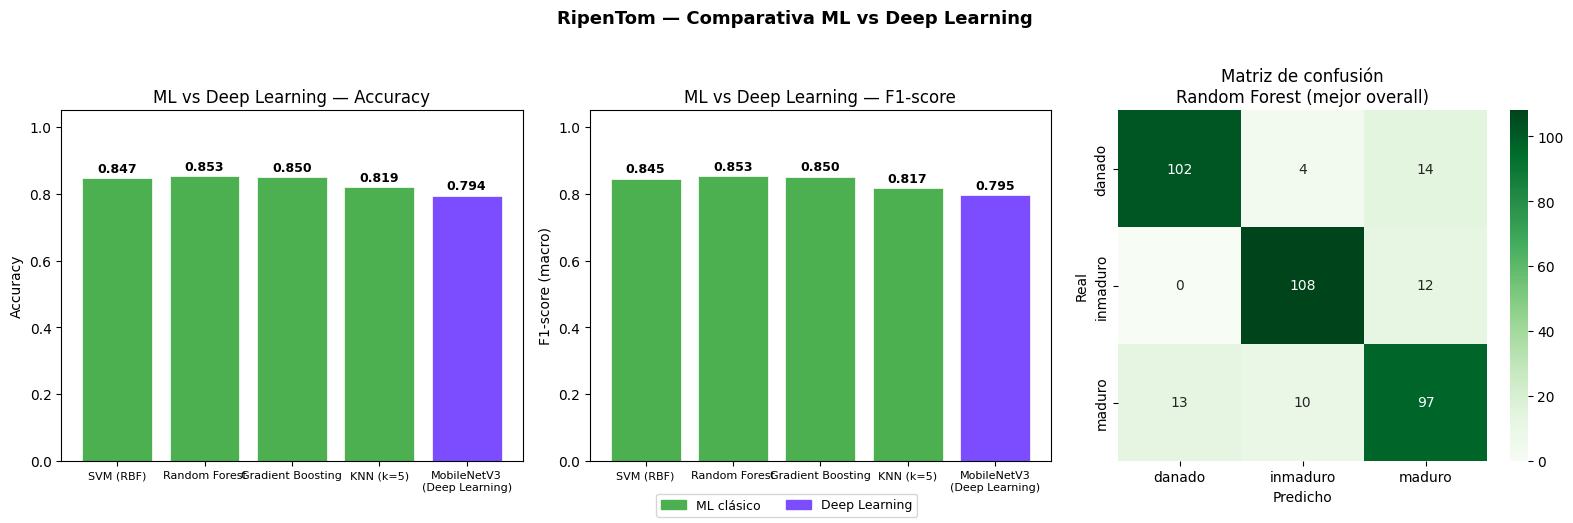


RESUMEN FINAL
SVM (RBF)              acc=0.847  f1=0.845
Random Forest          acc=0.853  f1=0.853
Gradient Boosting      acc=0.850  f1=0.850
KNN (k=5)              acc=0.819  f1=0.817
MobileNetV3 (DL)       acc=0.794  f1=0.795


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ── Tabla comparativa ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Accuracy comparativa
nombres  = list(resultados_ml.keys()) + ["MobileNetV3\n(Deep Learning)"]
accs     = [v["acc"] for v in resultados_ml.values()] + [best_val]
colores  = ["#4CAF50", "#4CAF50", "#4CAF50", "#4CAF50", "#7C4DFF"]

bars = axes[0].bar(nombres, accs, color=colores, edgecolor="white", linewidth=0.5)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("ML vs Deep Learning — Accuracy")
axes[0].tick_params(axis='x', labelsize=8)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{acc:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# 2) F1-score comparativa
# Calcular F1 de MobileNetV3
f1_dl = f1_score(best_labels, best_preds, average="macro")
f1s   = [v["f1"] for v in resultados_ml.values()] + [f1_dl]

bars2 = axes[1].bar(nombres, f1s, color=colores, edgecolor="white", linewidth=0.5)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("F1-score (macro)")
axes[1].set_title("ML vs Deep Learning — F1-score")
axes[1].tick_params(axis='x', labelsize=8)
for bar, f1 in zip(bars2, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{f1:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# 3) Matriz de confusión del mejor modelo overall
mejor_overall = mejor_ml if resultados_ml[mejor_ml]["acc"] >= best_val else "MobileNetV3"
if mejor_overall == "MobileNetV3":
    preds_finales, labels_finales = best_preds, best_labels
else:
    preds_finales = resultados_ml[mejor_ml]["preds"]
    labels_finales = y_val

cm = confusion_matrix(labels_finales, preds_finales)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples" if mejor_overall == "MobileNetV3" else "Greens",
            xticklabels=CLASES_NOMBRES, yticklabels=CLASES_NOMBRES, ax=axes[2])
axes[2].set_title(f"Matriz de confusión\n{mejor_overall} (mejor overall)")
axes[2].set_ylabel("Real")
axes[2].set_xlabel("Predicho")

ml_patch = mpatches.Patch(color="#4CAF50", label="ML clásico")
dl_patch = mpatches.Patch(color="#7C4DFF", label="Deep Learning")
fig.legend(handles=[ml_patch, dl_patch], loc="lower center", ncol=2, fontsize=9)

plt.suptitle("RipenTom — Comparativa ML vs Deep Learning", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("./comparativa_ml_vs_dl.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'='*50}")
print(f"RESUMEN FINAL")
print(f"{'='*50}")
for nombre, res in resultados_ml.items():
    print(f"{nombre:<22} acc={res['acc']:.3f}  f1={res['f1']:.3f}")
print(f"{'MobileNetV3 (DL)':<22} acc={best_val:.3f}  f1={f1_dl:.3f}")

### Extracción de características mejorada con análisis por bloques

Versión refinada de la extracción: además del vector global, la imagen se divide en **4 bloques de 2×2** y se extraen características base de cada uno. Los vectores de bloque se promedian y concatenan al global, logrando una representación espacialmente más rica sin perder compacidad.

In [1]:
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm

from skimage.feature import (
    graycomatrix,
    graycoprops,
    local_binary_pattern
)

# ============================================================
# DIVISIÓN EN 4 BLOQUES
# ============================================================
def dividir_en_bloques_2x2(img, mask):

    bloques = []

    h, w = img.shape[:2]

    mitad_h = h // 2
    mitad_w = w // 2

    coordenadas = [

        # P1
        (0, mitad_h, 0, mitad_w),

        # P2
        (0, mitad_h, mitad_w, w),

        # P3
        (mitad_h, h, 0, mitad_w),

        # P4
        (mitad_h, h, mitad_w, w)
    ]

    for (y1, y2, x1, x2) in coordenadas:

        bloque_img  = img[y1:y2, x1:x2]
        bloque_mask = mask[y1:y2, x1:x2]

        bloques.append((bloque_img, bloque_mask))

    return bloques


# ============================================================
# EXTRACCIÓN BASE
# ============================================================
def extraer_features_base(img, mask):

    # Resize uniforme
    img = cv2.resize(img, (224, 224))
    mask = cv2.resize(mask, (224, 224),
                      interpolation=cv2.INTER_NEAREST)

    mask = (mask > 0).astype(np.uint8)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    features = []

    mask_bool = mask > 0

    # evitar errores
    if np.sum(mask_bool) < 20:
        return np.zeros(120, dtype=np.float32)

    # ========================================================
    # AUX
    # ========================================================
    def stats_canal(canal):

        pixels = canal[mask_bool]

        return [
            np.mean(pixels),
            np.std(pixels),
            np.percentile(pixels, 25),
            np.percentile(pixels, 75)
        ]

    # ========================================================
    # HSV STATS
    # ========================================================
    for i in range(3):

        c = hsv[:, :, i]

        features.extend(stats_canal(c))

    # ========================================================
    # LAB STATS
    # ========================================================
    for i in range(3):

        c = lab[:, :, i]

        features.extend(stats_canal(c))

    # ========================================================
    # HSV HIST
    # ========================================================
    bins_h = 16
    bins_sv = 16

    hist_h = cv2.calcHist(
        [hsv], [0], mask,
        [bins_h], [0, 180]
    )

    hist_s = cv2.calcHist(
        [hsv], [1], mask,
        [bins_sv], [0, 256]
    )

    hist_v = cv2.calcHist(
        [hsv], [2], mask,
        [bins_sv], [0, 256]
    )

    hist_h = cv2.normalize(hist_h, hist_h).flatten()
    hist_s = cv2.normalize(hist_s, hist_s).flatten()
    hist_v = cv2.normalize(hist_v, hist_v).flatten()

    features.extend(hist_h)
    features.extend(hist_s)
    features.extend(hist_v)

    # ========================================================
    # GLCM
    # ========================================================
    glcm = graycomatrix(
        gris,
        distances=[1, 2],
        angles=[0, np.pi/4],
        levels=256,
        symmetric=True,
        normed=True
    )

    props = [
        'contrast',
        'correlation',
        'energy',
        'homogeneity',
        'dissimilarity'
    ]

    for prop in props:

        valores = graycoprops(glcm, prop)

        features.append(valores.mean())
        features.append(valores.std())

    # ========================================================
    # LBP
    # ========================================================
    lbp = local_binary_pattern(
        gris,
        P=8,
        R=1,
        method="uniform"
    )

    lbp_pixels = lbp[mask_bool]

    hist_lbp, _ = np.histogram(
        lbp_pixels,
        bins=np.arange(0, 11),
        range=(0, 10)
    )

    hist_lbp = hist_lbp.astype(np.float32)

    hist_lbp /= (hist_lbp.sum() + 1e-6)

    features.extend(hist_lbp)

    # ========================================================
    # DARK RATIO
    # ========================================================
    dark_mask = (
        (hsv[:, :, 2] < 50) &
        mask_bool
    )

    dark_ratio = (
        np.sum(dark_mask) /
        np.sum(mask_bool)
    )

    features.append(dark_ratio)

    # ========================================================
    # BROWN RATIO
    # ========================================================
    lower_brown = np.array([5, 40, 20])
    upper_brown = np.array([25, 255, 200])

    brown_mask = cv2.inRange(
        hsv,
        lower_brown,
        upper_brown
    )

    brown_ratio = (
        np.sum(brown_mask > 0) /
        np.sum(mask_bool)
    )

    features.append(brown_ratio)

    # ========================================================
    # REGIONES MARRONES
    # ========================================================
    num_labels, _ = cv2.connectedComponents(
        (brown_mask > 0).astype(np.uint8)
    )

    features.append(num_labels)

    # ========================================================
    # EDGE DENSITY
    # ========================================================
    edges = cv2.Canny(gris, 100, 200)

    edge_density = (
        np.sum(edges > 0) /
        np.sum(mask_bool)
    )

    features.append(edge_density)

    # ========================================================
    # SHAPE
    # ========================================================
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) > 0:

        cnt = max(contours, key=cv2.contourArea)

        area = cv2.contourArea(cnt)

        perimeter = cv2.arcLength(cnt, True)

        circularity = (
            4 * np.pi * area /
            (perimeter**2 + 1e-6)
        )

        x, y, w, h = cv2.boundingRect(cnt)

        aspect_ratio = w / (h + 1e-6)

    else:

        area = 0
        perimeter = 0
        circularity = 0
        aspect_ratio = 0

    features.extend([
        area,
        perimeter,
        circularity,
        aspect_ratio
    ])

    return np.array(features, dtype=np.float32)


# ============================================================
# EXTRACCIÓN FINAL (GLOBAL + BLOQUES)
# ============================================================
def extraer_features(img_path):

    img = cv2.imread(str(img_path))

    if img is None:
        raise ValueError(f"No se pudo leer la imagen: {img_path}")

    # ========================================================
    # MÁSCARA
    # ========================================================
    mask = np.any(img > 10, axis=2).astype(np.uint8)

    ys, xs = np.where(mask)

    if len(xs) == 0 or len(ys) == 0:
        raise ValueError(f"No se detectó objeto: {img_path}")

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    img = img[y1:y2, x1:x2]
    mask = mask[y1:y2, x1:x2]

    # ========================================================
    # FEATURES GLOBALES
    # ========================================================
    features_globales = extraer_features_base(
        img,
        mask
    )

    # ========================================================
    # BLOQUES
    # ========================================================
    bloques = dividir_en_bloques_2x2(img, mask)

    features_bloques = []

    for bloque_img, bloque_mask in bloques:

        if np.sum(bloque_mask) < 50:
            continue

        f = extraer_features_base(
            bloque_img,
            bloque_mask
        )

        features_bloques.append(f)

    # ========================================================
    # PROMEDIO FEATURES BLOQUES
    # ========================================================
    if len(features_bloques) > 0:

        features_bloques = np.array(features_bloques)

        promedio_bloques = features_bloques.mean(axis=0)

    else:

        promedio_bloques = np.zeros_like(
            features_globales
        )

    # ========================================================
    # CONCATENAR
    # ========================================================
    features_finales = np.concatenate([
        features_globales,
        promedio_bloques
    ])

    return features_finales.astype(np.float32)


# ============================================================
# DATASET
# ============================================================
SPLIT_PATH = Path("./ripentom_split")

CLASES_NOMBRES = [
    "danado",
    "inmaduro",
    "maduro"
]

X_train, y_train = [], []
X_val, y_val = [], []

for split, X, y in [

    ("train", X_train, y_train),
    ("val", X_val, y_val)

]:

    for idx, clase in enumerate(CLASES_NOMBRES):

        carpeta = SPLIT_PATH / split / clase

        imgs = list(carpeta.glob("*.*"))

        print(f"Extrayendo {split}/{clase}: {len(imgs)} imágenes...")

        for img_path in tqdm(imgs, leave=False):

            try:

                feats = extraer_features(img_path)

                X.append(feats)

                y.append(idx)

            except Exception as e:

                print(f"Error en {img_path}: {e}")

X_train = np.array(X_train)
y_train = np.array(y_train)

X_val = np.array(X_val)
y_val = np.array(y_val)

print("\n✓ Dataset listo")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

Extrayendo train/danado: 280 imágenes...


Extrayendo train/inmaduro: 280 imágenes...


Extrayendo train/maduro: 280 imágenes...


Extrayendo val/danado: 120 imágenes...


Extrayendo val/inmaduro: 120 imágenes...


Extrayendo val/maduro: 120 imágenes...



✓ Dataset listo
X_train: (840, 200)
X_val: (360, 200)


### Re-entrenamiento con características mejoradas

Se repite el entrenamiento de los 4 modelos ML usando el nuevo vector de características (global + bloques). Esto permite comparar si la representación enriquecida mejora el rendimiento respecto a la extracción simple anterior.

In [2]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
import time
import joblib

# Escalar features (importante para SVM y KNN)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

modelos = {
    "SVM (RBF)":           SVC(kernel="rbf", C=10, gamma="scale"),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "KNN (k=5)":           KNeighborsClassifier(n_neighbors=5),
}

resultados_ml = {}

print(f"{'Modelo':<22} {'Accuracy':>10} {'F1-macro':>10} {'Tiempo':>10}")
print("─" * 56)

for nombre, modelo in modelos.items():
    # SVM y KNN usan datos escalados
    usa_escala = nombre in ["SVM (RBF)", "KNN (k=5)"]
    Xtr = X_train_sc if usa_escala else X_train
    Xv  = X_val_sc   if usa_escala else X_val

    t0 = time.time()
    modelo.fit(Xtr, y_train)
    preds = modelo.predict(Xv)
    elapsed = time.time() - t0

    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds, average="macro")
    resultados_ml[nombre] = {"acc": acc, "f1": f1, "preds": preds}

    print(f"{nombre:<22} {acc:>10.3f} {f1:>10.3f} {elapsed:>9.1f}s")

# Reporte detallado del mejor ML
mejor_ml = max(resultados_ml, key=lambda k: resultados_ml[k]["acc"])
print(f"\nMejor modelo ML: {mejor_ml}")
print(classification_report(y_val, resultados_ml[mejor_ml]["preds"],
                             target_names=CLASES_NOMBRES))

joblib.dump(modelos["Random Forest"], "modelo_tomate_rf.joblib")
joblib.dump(scaler, "scaler.joblib")

print("Modelos guardados ✓")

Modelo                   Accuracy   F1-macro     Tiempo
────────────────────────────────────────────────────────
SVM (RBF)                   0.867      0.865       0.1s
Random Forest               0.856      0.856       1.7s
Gradient Boosting           0.847      0.847      12.6s
KNN (k=5)                   0.822      0.820       0.1s

Mejor modelo ML: SVM (RBF)
              precision    recall  f1-score   support

      danado       0.86      0.82      0.84       120
    inmaduro       0.91      0.99      0.95       120
      maduro       0.82      0.78      0.80       120

    accuracy                           0.87       360
   macro avg       0.86      0.87      0.86       360
weighted avg       0.86      0.87      0.86       360

Modelos guardados ✓


10 — Gráfica comparativa ML vs Deep Learning

## 📈 10. Comparativa final — ML clásico vs. Deep Learning

Se genera una figura de 3 paneles para comparar todos los enfoques:

1. **Accuracy** de cada modelo (barras verdes = ML, morada = MobileNetV3).  
2. **F1-score macro** de cada modelo.  
3. **Matriz de confusión** del modelo con mejor accuracy global.

Esto permite decidir qué estrategia es más efectiva para el clasificador de tomates.

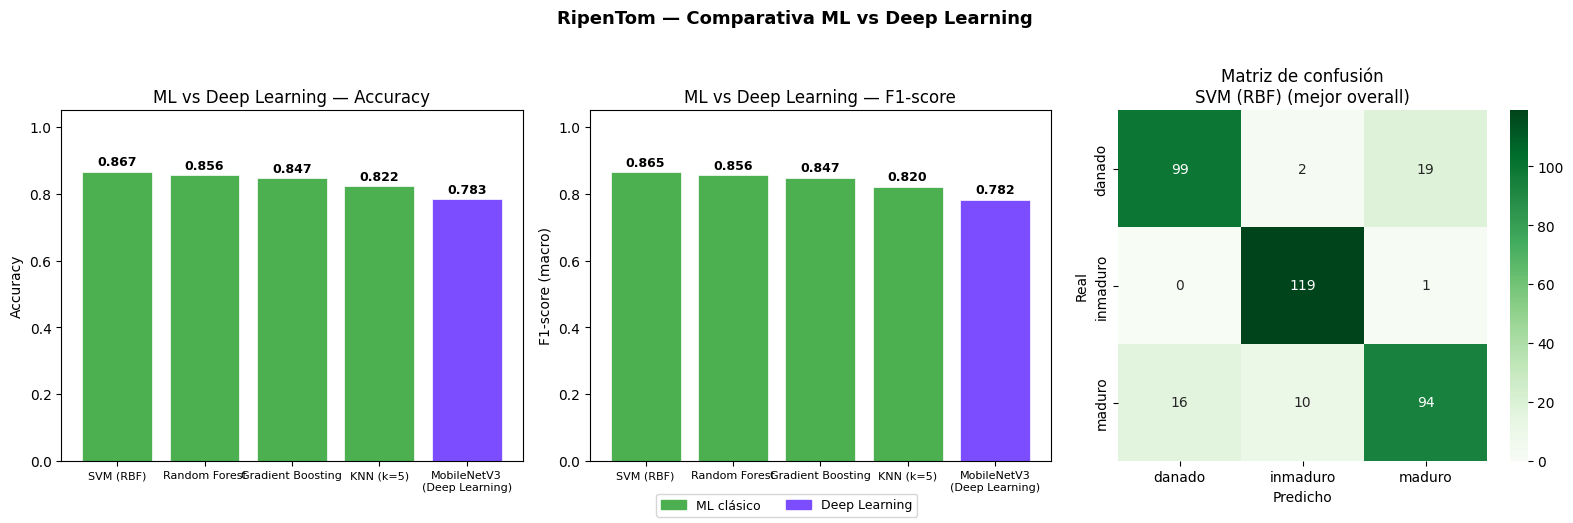


RESUMEN FINAL
SVM (RBF)              acc=0.867  f1=0.865
Random Forest          acc=0.856  f1=0.856
Gradient Boosting      acc=0.847  f1=0.847
KNN (k=5)              acc=0.822  f1=0.820
MobileNetV3 (DL)       acc=0.783  f1=0.782


In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ── Tabla comparativa ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Accuracy comparativa
nombres  = list(resultados_ml.keys()) + ["MobileNetV3\n(Deep Learning)"]
accs     = [v["acc"] for v in resultados_ml.values()] + [best_val]
colores  = ["#4CAF50", "#4CAF50", "#4CAF50", "#4CAF50", "#7C4DFF"]

bars = axes[0].bar(nombres, accs, color=colores, edgecolor="white", linewidth=0.5)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("ML vs Deep Learning — Accuracy")
axes[0].tick_params(axis='x', labelsize=8)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{acc:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# 2) F1-score comparativa
# Calcular F1 de MobileNetV3
f1_dl = f1_score(best_labels, best_preds, average="macro")
f1s   = [v["f1"] for v in resultados_ml.values()] + [f1_dl]

bars2 = axes[1].bar(nombres, f1s, color=colores, edgecolor="white", linewidth=0.5)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("F1-score (macro)")
axes[1].set_title("ML vs Deep Learning — F1-score")
axes[1].tick_params(axis='x', labelsize=8)
for bar, f1 in zip(bars2, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{f1:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# 3) Matriz de confusión del mejor modelo overall
mejor_overall = mejor_ml if resultados_ml[mejor_ml]["acc"] >= best_val else "MobileNetV3"
if mejor_overall == "MobileNetV3":
    preds_finales, labels_finales = best_preds, best_labels
else:
    preds_finales = resultados_ml[mejor_ml]["preds"]
    labels_finales = y_val

cm = confusion_matrix(labels_finales, preds_finales)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples" if mejor_overall == "MobileNetV3" else "Greens",
            xticklabels=CLASES_NOMBRES, yticklabels=CLASES_NOMBRES, ax=axes[2])
axes[2].set_title(f"Matriz de confusión\n{mejor_overall} (mejor overall)")
axes[2].set_ylabel("Real")
axes[2].set_xlabel("Predicho")

ml_patch = mpatches.Patch(color="#4CAF50", label="ML clásico")
dl_patch = mpatches.Patch(color="#7C4DFF", label="Deep Learning")
fig.legend(handles=[ml_patch, dl_patch], loc="lower center", ncol=2, fontsize=9)

plt.suptitle("RipenTom — Comparativa ML vs Deep Learning", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("./comparativa_ml_vs_dl.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'='*50}")
print(f"RESUMEN FINAL")
print(f"{'='*50}")
for nombre, res in resultados_ml.items():
    print(f"{nombre:<22} acc={res['acc']:.3f}  f1={res['f1']:.3f}")
print(f"{'MobileNetV3 (DL)':<22} acc={best_val:.3f}  f1={f1_dl:.3f}")

---

## ✅ Resumen del proyecto — RipenTom

| Etapa | Descripción |
|---|---|
| **Dataset** | ~400 imágenes segmentadas (fondo negro) en 3 clases: *danado*, *inmaduro*, *maduro* |
| **Split** | 70 % train / 30 % validación, semilla fija = 42 |
| **Deep Learning** | MobileNetV3-Small con fine-tuning en 2 fases (15 épocas totales) |
| **ML clásico** | SVM, Random Forest, Gradient Boosting, KNN sobre vector de 240 features |
| **Evaluación** | Accuracy, F1-macro, matriz de confusión |
| **Mejor modelo** | Determinado automáticamente al final de la comparativa |
